In [1]:
"""
Synthetic dataset generator for the Daily Reflection Tree project.

Generates realistic, varied daily reflection records for demonstration
purposes. This is SYNTHETIC data — no real personal journal entries are
used or required, which sidesteps the privacy concerns of using someone's
actual private reflections in a public GitHub repo.

Design choices (documented so the notebooks can explain them honestly):
- mood, energy, and productivity are drawn from a shared latent "day quality"
  factor plus independent noise, so they are realistically correlated with
  each other (not random/independent), the way real self-reported wellbeing
  measures are.
- reflection text is composed from topic-specific sentence fragments chosen
  according to the day's sentiment tier (positive/neutral/negative), so the
  words used are honestly consistent with the numeric ratings, and later
  sentiment analysis in the notebooks discovers a real, non-fabricated
  relationship between text and ratings rather than random noise.
- productivity has a small realistic weekday/weekend effect, and a small
  autocorrelation with the previous day (a good day tends to be followed by
  a slightly-above-average day), which is what makes the "predict next-day
  productivity" ML problem later in the project meaningful rather than
  trying to predict pure noise.
- ~8% of days are randomly skipped (no reflection written), which is
  necessary for the streak-analysis section of the project to have
  anything real to measure.
"""

from __future__ import annotations

import random
from datetime import date, timedelta

import numpy as np
import pandas as pd

RANDOM_SEED = 42

# ---------------------------------------------------------------------------
# Topic definitions: each topic has tag options and sentence fragments split
# by sentiment tier, so generated text stays honest to the day's mood.
# ---------------------------------------------------------------------------
TOPICS = {
    "learning": {
        "tags": ["learning", "python", "data science", "study", "coding"],
        "positive": [
            "Today I spent a few hours learning {skill} and finally understood how {concept} works.",
            "I made real progress on {skill} today — {concept} finally clicked after struggling with it for a while.",
            "Worked through a tricky problem involving {concept} and felt genuinely satisfied once it worked.",
            "Had a productive study session on {skill}, especially around {concept}.",
        ],
        "neutral": [
            "Spent some time reviewing {skill}, mostly going over {concept} again.",
            "Did a bit of {skill} practice today, nothing major, just consolidating {concept}.",
            "Read through some notes on {concept} but didn't get much hands-on {skill} practice done.",
        ],
        "negative": [
            "Tried to study {skill} today but kept getting stuck on {concept} and felt frustrated.",
            "Struggled a lot with {concept} — {skill} is starting to feel overwhelming.",
            "Barely got through any {skill} today, my focus on {concept} kept slipping.",
        ],
        "skill": ["Python", "machine learning", "SQL", "statistics", "data visualization", "pandas"],
        "concept": ["feature engineering", "gradient descent", "joins", "hypothesis testing", "overfitting", "correlation vs causation"],
    },
    "work": {
        "tags": ["work", "career", "productivity", "meetings"],
        "positive": [
            "Had a really productive day at work — cleared most of my {task} and even helped a coworker with theirs.",
            "Finished {task} ahead of schedule today, which felt great going into the weekend.",
            "Good day overall, made solid progress on {task} and the team meeting went smoothly.",
        ],
        "neutral": [
            "Fairly average day at work, mostly just handled {task} without much excitement.",
            "Spent most of the day on {task}, nothing particularly noteworthy happened.",
        ],
        "negative": [
            "Rough day at work — {task} kept getting delayed and I felt behind the whole time.",
            "Struggled to focus on {task} today, kept getting pulled into unnecessary meetings.",
            "Felt pretty drained after dealing with {task}, didn't get much else done.",
        ],
        "task": ["the quarterly report", "a backlog of emails", "a client presentation", "a few pending tickets", "the project deadline"],
    },
    "family": {
        "tags": ["family", "friends", "weekend", "relationships"],
        "positive": [
            "Spent quality time with {people} today, it was really nice to just relax and catch up.",
            "Had a lovely time with {people} — we {activity} and it lifted my mood a lot.",
            "Great day with {people}, nothing planned but it turned out to be one of the better days recently.",
        ],
        "neutral": [
            "Saw {people} briefly today, exchanged a few messages, nothing major.",
            "Quiet day, spoke with {people} for a bit over the phone.",
        ],
        "negative": [
            "Had a small disagreement with {people} today which put a bit of a damper on the day.",
            "Missed a call from {people} and felt a bit guilty about not making more time for them lately.",
        ],
        "people": ["my family", "an old friend", "my parents", "a close friend", "my sibling"],
        "activity": ["went for a long walk", "cooked dinner together", "watched a movie", "just talked for hours"],
    },
    "health": {
        "tags": ["health", "exercise", "fitness", "wellbeing"],
        "positive": [
            "Went for a {exercise} this morning and felt really energized for the rest of the day.",
            "Managed to fit in a good {exercise} session, my energy levels were noticeably higher afterward.",
            "Felt physically great today after a solid {exercise} routine.",
        ],
        "neutral": [
            "Did a light {exercise} session, nothing intense, just kept the habit going.",
            "Skipped my usual {exercise} today but ate reasonably well.",
        ],
        "negative": [
            "Didn't get any {exercise} in today and felt sluggish because of it.",
            "Woke up tired and skipped {exercise} entirely, energy was low all day.",
        ],
        "exercise": ["run", "gym workout", "yoga session", "walk", "swim"],
    },
    "stress": {
        "tags": ["stress", "exam", "deadline", "anxiety"],
        "positive": [
            "Despite the upcoming {stressor}, I felt in control today and made good progress preparing for it.",
            "Managed my anxiety about the {stressor} well today by breaking the work into smaller pieces.",
        ],
        "neutral": [
            "Thinking about the {stressor} a lot today but haven't really started preparing yet.",
            "The {stressor} is coming up soon, feeling a mix of nervous and okay about it.",
        ],
        "negative": [
            "Feeling really stressed about the {stressor} — couldn't focus on much else today.",
            "The {stressor} is weighing on me a lot, didn't sleep well because of it.",
            "Anxiety about the {stressor} made it hard to get anything meaningful done today.",
        ],
        "stressor": ["exam", "project deadline", "job interview", "presentation", "assignment due date"],
    },
    "travel": {
        "tags": ["travel", "weekend", "adventure"],
        "positive": [
            "Took a short trip to {place} today, it was a nice change of scenery and really refreshing.",
            "Explored {place} for the first time — such a great way to break the routine.",
        ],
        "neutral": [
            "Thinking about planning a trip to {place} sometime soon, haven't decided yet.",
            "Looked into travel options for {place}, nothing booked yet.",
        ],
        "negative": [
            "Trip to {place} got cancelled today, which was disappointing.",
        ],
        "place": ["the nearby hill station", "a new part of the city", "the coast", "a local market", "the countryside"],
    },
    "hobbies": {
        "tags": ["hobbies", "reading", "music", "creativity"],
        "positive": [
            "Spent the evening on {hobby}, completely lost track of time — it was exactly what I needed.",
            "Made good progress on {hobby} today, felt really fulfilling.",
        ],
        "neutral": [
            "Did a bit of {hobby} but got distracted halfway through.",
            "Thought about picking {hobby} back up today but didn't get to it.",
        ],
        "negative": [
            "Wanted to spend time on {hobby} today but couldn't find the motivation.",
        ],
        "hobby": ["reading", "playing guitar", "sketching", "writing", "photography"],
    },
    "rest": {
        "tags": ["rest", "relaxation", "weekend", "sleep"],
        "positive": [
            "Took a proper rest day today, slept well and just recharged — much needed.",
            "Did absolutely nothing productive today and it felt great, exactly the break I needed.",
        ],
        "neutral": [
            "Fairly lazy day overall, mixed a bit of rest with a few small chores.",
        ],
        "negative": [
            "Couldn't really relax today even though I had the time, mind was too restless.",
            "Slept badly last night and it affected the whole day.",
        ],
    },
}

TOPIC_NAMES = list(TOPICS.keys())

# Generic closing remarks, appended to ~45% of reflections regardless of
# topic, purely to add natural variation so combinatorially few reflections
# end up as exact duplicates of each other.
CLOSING_REMARKS = {
    "positive": [
        "Feeling optimistic about tomorrow.",
        "Overall a pretty good day.",
        "Grateful for how the day turned out.",
        "Looking forward to more days like this.",
        "Ending the day in a good mood.",
    ],
    "neutral": [
        "Just an ordinary day overall.",
        "Nothing particularly stands out about today.",
        "A fairly typical day, all things considered.",
        "Ready to see what tomorrow brings.",
    ],
    "negative": [
        "Hoping tomorrow goes a bit better.",
        "Need to get more rest tonight.",
        "Today was harder than expected.",
        "Trying not to be too hard on myself about it.",
    ],
}


def _sentiment_tier(day_quality: float) -> str:
    if day_quality >= 0.62:
        return "positive"
    if day_quality <= 0.38:
        return "negative"
    return "neutral"


def _fill_template(template: str, topic_data: dict, rng: random.Random) -> str:
    result = template
    for slot in ["skill", "concept", "task", "people", "activity", "exercise", "stressor", "place", "hobby"]:
        if "{" + slot + "}" in result and slot in topic_data:
            result = result.replace("{" + slot + "}", rng.choice(topic_data[slot]))
    return result


def generate_reflection_text(topic: str, day_quality: float, rng: random.Random) -> str:
    topic_data = TOPICS[topic]
    tier = _sentiment_tier(day_quality)
    templates = topic_data[tier]
    n_sentences = rng.choice([1, 1, 2])  # mostly 1 sentence, sometimes 2
    chosen = rng.sample(templates, min(n_sentences, len(templates)))
    sentences = [_fill_template(t, topic_data, rng) for t in chosen]

    if rng.random() < 0.45:
        sentences.append(rng.choice(CLOSING_REMARKS[tier]))

    return " ".join(sentences)


def generate_tags(topic: str, rng: random.Random) -> str:
    pool = TOPICS[topic]["tags"]
    n = rng.choice([1, 2, 2, 3])
    chosen = rng.sample(pool, min(n, len(pool)))
    return ", ".join(chosen)


def generate_dataset(n_days: int = 500, end_date: date | None = None, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Generate n_days worth of synthetic daily reflections ending at end_date."""
    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)

    if end_date is None:
        end_date = date.today()
    start_date = end_date - timedelta(days=n_days - 1)
    all_dates = [start_date + timedelta(days=i) for i in range(n_days)]

    records = []
    prev_quality = 0.5  # latent "how the previous day went", drives autocorrelation

    for d in all_dates:
        # ~8% of days have no reflection at all (realistic missed days)
        if rng.random() < 0.08:
            continue

        is_weekend = d.weekday() >= 5

        # Latent day-quality factor: mostly random, with mild pull toward the
        # previous day's quality (autocorrelation) and a small weekend boost.
        base = np_rng.normal(loc=0.5, scale=0.18)
        autocorr = 0.15 * (prev_quality - 0.5)
        weekend_boost = 0.05 if is_weekend else 0.0
        day_quality = float(np.clip(base + autocorr + weekend_boost, 0.02, 0.98))
        prev_quality = day_quality

        # Ratings derived from day_quality + independent noise per rating,
        # so mood/energy/productivity are correlated but not identical.
        def rating_from_quality(center_shift: float = 0.0, noise_scale: float = 1.3) -> int:
            val = 1 + (day_quality + center_shift) * 9 + np_rng.normal(0, noise_scale)
            return int(np.clip(round(val), 1, 10))

        mood = rating_from_quality(noise_scale=1.1)
        energy = rating_from_quality(noise_scale=1.3)
        # Productivity dips slightly on weekends (realistic pattern)
        productivity = rating_from_quality(center_shift=(-0.08 if is_weekend else 0.02), noise_scale=1.3)

        topic = rng.choices(
            TOPIC_NAMES,
            weights=[3, 3, 2, 2, 1.5, 1, 1.5, 2] if not is_weekend else [1.5, 1, 3, 2, 1, 2, 2, 3],
        )[0]

        reflection = generate_reflection_text(topic, day_quality, rng)
        tags = generate_tags(topic, rng)

        records.append({
            "date": d.isoformat(),
            "reflection": reflection,
            "mood": mood,
            "energy": energy,
            "productivity": productivity,
            "tags": tags,
        })

    return pd.DataFrame(records)


if __name__ == "__main__":
    df = generate_dataset(n_days=560)  # ~8% of days are skipped, so target extra to net 500+
    print(f"Generated {len(df)} reflection records (some days skipped, as documented above)")
    print(df.head(10).to_string())
    df.to_csv("data/raw/daily_reflections.csv", index=False)
    print("\nSaved to data/raw/daily_reflections.csv")


Generated 518 reflection records (some days skipped, as documented above)
         date                                                                                                                         reflection  mood  energy  productivity                         tags
0  2025-01-30                                              Spent some time reviewing machine learning, mostly going over gradient descent again.     5       7             7                       coding
1  2025-01-31  Tried to study data visualization today but kept getting stuck on overfitting and felt frustrated. Need to get more rest tonight.     1       3             2  python, study, data science
2  2025-02-01                 Fairly lazy day overall, mixed a bit of rest with a few small chores. Nothing particularly stands out about today.     5       7             6                weekend, rest
3  2025-02-02                                     Read through some notes on feature engineering but didn't get much h

In [2]:
df.shape

(518, 6)

In [3]:
df.columns

Index(['date', 'reflection', 'mood', 'energy', 'productivity', 'tags'], dtype='object')

# 🌳 Daily Reflection Tree

## Cell 1 — Setup (imports + folders)

In [4]:
import os, re, random, ast
from datetime import date, timedelta
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)
RANDOM_SEED = 42

for folder in ["data/raw", "data/processed", "visualizations", "models"]:
    os.makedirs(folder, exist_ok=True)

print("Folders ready:", os.listdir("."))

Folders ready: ['.ipynb_checkpoints', 'data', 'models', 'Untitled.ipynb', 'visualizations']


## Cell 2 — Dataset generator (topic/template definitions)

In [5]:
TOPICS = {
    "learning": {
        "tags": ["learning", "python", "data science", "study", "coding"],
        "positive": [
            "Today I spent a few hours learning {skill} and finally understood how {concept} works.",
            "I made real progress on {skill} today — {concept} finally clicked after struggling with it for a while.",
            "Worked through a tricky problem involving {concept} and felt genuinely satisfied once it worked.",
            "Had a productive study session on {skill}, especially around {concept}.",
        ],
        "neutral": [
            "Spent some time reviewing {skill}, mostly going over {concept} again.",
            "Did a bit of {skill} practice today, nothing major, just consolidating {concept}.",
            "Read through some notes on {concept} but didn't get much hands-on {skill} practice done.",
        ],
        "negative": [
            "Tried to study {skill} today but kept getting stuck on {concept} and felt frustrated.",
            "Struggled a lot with {concept} — {skill} is starting to feel overwhelming.",
            "Barely got through any {skill} today, my focus on {concept} kept slipping.",
        ],
        "skill": ["Python", "machine learning", "SQL", "statistics", "data visualization", "pandas"],
        "concept": ["feature engineering", "gradient descent", "joins", "hypothesis testing", "overfitting", "correlation vs causation"],
    },
    "work": {
        "tags": ["work", "career", "productivity", "meetings"],
        "positive": [
            "Had a really productive day at work — cleared most of my {task} and even helped a coworker with theirs.",
            "Finished {task} ahead of schedule today, which felt great going into the weekend.",
            "Good day overall, made solid progress on {task} and the team meeting went smoothly.",
        ],
        "neutral": [
            "Fairly average day at work, mostly just handled {task} without much excitement.",
            "Spent most of the day on {task}, nothing particularly noteworthy happened.",
        ],
        "negative": [
            "Rough day at work — {task} kept getting delayed and I felt behind the whole time.",
            "Struggled to focus on {task} today, kept getting pulled into unnecessary meetings.",
            "Felt pretty drained after dealing with {task}, didn't get much else done.",
        ],
        "task": ["the quarterly report", "a backlog of emails", "a client presentation", "a few pending tickets", "the project deadline"],
    },
    "family": {
        "tags": ["family", "friends", "weekend", "relationships"],
        "positive": [
            "Spent quality time with {people} today, it was really nice to just relax and catch up.",
            "Had a lovely time with {people} — we {activity} and it lifted my mood a lot.",
            "Great day with {people}, nothing planned but it turned out to be one of the better days recently.",
        ],
        "neutral": [
            "Saw {people} briefly today, exchanged a few messages, nothing major.",
            "Quiet day, spoke with {people} for a bit over the phone.",
        ],
        "negative": [
            "Had a small disagreement with {people} today which put a bit of a damper on the day.",
            "Missed a call from {people} and felt a bit guilty about not making more time for them lately.",
        ],
        "people": ["my family", "an old friend", "my parents", "a close friend", "my sibling"],
        "activity": ["went for a long walk", "cooked dinner together", "watched a movie", "just talked for hours"],
    },
    "health": {
        "tags": ["health", "exercise", "fitness", "wellbeing"],
        "positive": [
            "Went for a {exercise} this morning and felt really energized for the rest of the day.",
            "Managed to fit in a good {exercise} session, my energy levels were noticeably higher afterward.",
            "Felt physically great today after a solid {exercise} routine.",
        ],
        "neutral": [
            "Did a light {exercise} session, nothing intense, just kept the habit going.",
            "Skipped my usual {exercise} today but ate reasonably well.",
        ],
        "negative": [
            "Didn't get any {exercise} in today and felt sluggish because of it.",
            "Woke up tired and skipped {exercise} entirely, energy was low all day.",
        ],
        "exercise": ["run", "gym workout", "yoga session", "walk", "swim"],
    },
    "stress": {
        "tags": ["stress", "exam", "deadline", "anxiety"],
        "positive": [
            "Despite the upcoming {stressor}, I felt in control today and made good progress preparing for it.",
            "Managed my anxiety about the {stressor} well today by breaking the work into smaller pieces.",
        ],
        "neutral": [
            "Thinking about the {stressor} a lot today but haven't really started preparing yet.",
            "The {stressor} is coming up soon, feeling a mix of nervous and okay about it.",
        ],
        "negative": [
            "Feeling really stressed about the {stressor} — couldn't focus on much else today.",
            "The {stressor} is weighing on me a lot, didn't sleep well because of it.",
            "Anxiety about the {stressor} made it hard to get anything meaningful done today.",
        ],
        "stressor": ["exam", "project deadline", "job interview", "presentation", "assignment due date"],
    },
    "travel": {
        "tags": ["travel", "weekend", "adventure"],
        "positive": [
            "Took a short trip to {place} today, it was a nice change of scenery and really refreshing.",
            "Explored {place} for the first time — such a great way to break the routine.",
        ],
        "neutral": [
            "Thinking about planning a trip to {place} sometime soon, haven't decided yet.",
            "Looked into travel options for {place}, nothing booked yet.",
        ],
        "negative": [
            "Trip to {place} got cancelled today, which was disappointing.",
        ],
        "place": ["the nearby hill station", "a new part of the city", "the coast", "a local market", "the countryside"],
    },
    "hobbies": {
        "tags": ["hobbies", "reading", "music", "creativity"],
        "positive": [
            "Spent the evening on {hobby}, completely lost track of time — it was exactly what I needed.",
            "Made good progress on {hobby} today, felt really fulfilling.",
        ],
        "neutral": [
            "Did a bit of {hobby} but got distracted halfway through.",
            "Thought about picking {hobby} back up today but didn't get to it.",
        ],
        "negative": [
            "Wanted to spend time on {hobby} today but couldn't find the motivation.",
        ],
        "hobby": ["reading", "playing guitar", "sketching", "writing", "photography"],
    },
    "rest": {
        "tags": ["rest", "relaxation", "weekend", "sleep"],
        "positive": [
            "Took a proper rest day today, slept well and just recharged — much needed.",
            "Did absolutely nothing productive today and it felt great, exactly the break I needed.",
        ],
        "neutral": [
            "Fairly lazy day overall, mixed a bit of rest with a few small chores.",
        ],
        "negative": [
            "Couldn't really relax today even though I had the time, mind was too restless.",
            "Slept badly last night and it affected the whole day.",
        ],
    },
}
TOPIC_NAMES = list(TOPICS.keys())

CLOSING_REMARKS = {
    "positive": ["Feeling optimistic about tomorrow.", "Overall a pretty good day.", "Grateful for how the day turned out.",
                 "Looking forward to more days like this.", "Ending the day in a good mood."],
    "neutral": ["Just an ordinary day overall.", "Nothing particularly stands out about today.",
                "A fairly typical day, all things considered.", "Ready to see what tomorrow brings."],
    "negative": ["Hoping tomorrow goes a bit better.", "Need to get more rest tonight.",
                 "Today was harder than expected.", "Trying not to be too hard on myself about it."],
}

print("Topic templates loaded:", len(TOPICS), "topics")

Topic templates loaded: 8 topics


## Cell 3 — Dataset generation functions + run it

In [6]:
def _sentiment_tier(q):
    if q >= 0.62: return "positive"
    if q <= 0.38: return "negative"
    return "neutral"

def _fill_template(template, topic_data, rng):
    result = template
    for slot in ["skill","concept","task","people","activity","exercise","stressor","place","hobby"]:
        if "{"+slot+"}" in result and slot in topic_data:
            result = result.replace("{"+slot+"}", rng.choice(topic_data[slot]))
    return result

def generate_reflection_text(topic, day_quality, rng):
    topic_data = TOPICS[topic]
    tier = _sentiment_tier(day_quality)
    templates = topic_data[tier]
    n_sentences = rng.choice([1, 1, 2])
    chosen = rng.sample(templates, min(n_sentences, len(templates)))
    sentences = [_fill_template(t, topic_data, rng) for t in chosen]
    if rng.random() < 0.45:
        sentences.append(rng.choice(CLOSING_REMARKS[tier]))
    return " ".join(sentences)

def generate_tags(topic, rng):
    pool = TOPICS[topic]["tags"]
    n = rng.choice([1, 2, 2, 3])
    return ", ".join(rng.sample(pool, min(n, len(pool))))

def generate_dataset(n_days=560, end_date=None, seed=RANDOM_SEED):
    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)
    if end_date is None:
        end_date = date.today()
    start_date = end_date - timedelta(days=n_days - 1)
    all_dates = [start_date + timedelta(days=i) for i in range(n_days)]
    records = []
    prev_quality = 0.5
    for d in all_dates:
        if rng.random() < 0.08:
            continue
        is_weekend = d.weekday() >= 5
        base = np_rng.normal(loc=0.5, scale=0.18)
        autocorr = 0.15 * (prev_quality - 0.5)
        weekend_boost = 0.05 if is_weekend else 0.0
        day_quality = float(np.clip(base + autocorr + weekend_boost, 0.02, 0.98))
        prev_quality = day_quality

        def rating_from_quality(center_shift=0.0, noise_scale=1.3):
            val = 1 + (day_quality + center_shift) * 9 + np_rng.normal(0, noise_scale)
            return int(np.clip(round(val), 1, 10))

        mood = rating_from_quality(noise_scale=1.1)
        energy = rating_from_quality(noise_scale=1.3)
        productivity = rating_from_quality(center_shift=(-0.08 if is_weekend else 0.02), noise_scale=1.3)
        topic = rng.choices(TOPIC_NAMES, weights=[3,3,2,2,1.5,1,1.5,2] if not is_weekend else [1.5,1,3,2,1,2,2,3])[0]
        reflection = generate_reflection_text(topic, day_quality, rng)
        tags = generate_tags(topic, rng)
        records.append({"date": d.isoformat(), "reflection": reflection, "mood": mood,
                         "energy": energy, "productivity": productivity, "tags": tags})
    return pd.DataFrame(records)

df_raw = generate_dataset(n_days=560)
print(f"Generated {len(df_raw)} reflection records")

os.makedirs("data/raw", exist_ok=True)
df_raw.to_csv("data/raw/daily_reflections.csv", index=False)
print("Saved to data/raw/daily_reflections.csv")
df_raw.head()

Generated 518 reflection records
Saved to data/raw/daily_reflections.csv


,date,reflection,mood,energy,productivity,tags
0,2025-01-30,"Spent some time reviewing machine learning, mostly going over gradient descent again.",5,7,7,coding
1,2025-01-31,Tried to study data visualization today but kept getting stuck on overfitting and felt frustrated. Need to get more ...,1,3,2,"python, study, data science"
2,2025-02-01,"Fairly lazy day overall, mixed a bit of rest with a few small chores. Nothing particularly stands out about today.",5,7,6,"weekend, rest"
3,2025-02-02,Read through some notes on feature engineering but didn't get much hands-on SQL practice done.,7,7,4,study
4,2025-02-04,Thinking about the exam a lot today but haven't really started preparing yet. Nothing particularly stands out about ...,5,7,6,"stress, anxiety"


## Cell 4 — Load and explore

In [7]:
df = pd.read_csv("data/raw/daily_reflections.csv")
print(df.shape)
df.info()
df.describe()

(518, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          518 non-null    object
 1   reflection    518 non-null    object
 2   mood          518 non-null    int64 
 3   energy        518 non-null    int64 
 4   productivity  518 non-null    int64 
 5   tags          518 non-null    object
dtypes: int64(3), object(3)
memory usage: 24.4+ KB


,mood,energy,productivity
count,518.000000,518.000000,518.000000
mean,5.469112,5.465251,5.376448
std,1.932620,2.050086,2.041917
min,1.000000,1.000000,1.000000
25%,4.000000,4.000000,4.000000
50%,6.000000,5.000000,5.000000
75%,7.000000,7.000000,7.000000
max,10.000000,10.000000,10.000000


## Cell 5 — Data quality checks

In [8]:
print("Missing values:\n", df.isnull().sum())
print("\nFully duplicate rows:", df.duplicated().sum())
print("Duplicate reflection text:", df.duplicated(subset=["reflection"]).sum())

df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce")
print("Invalid dates:", df["date_parsed"].isna().sum())

for col in ["mood", "energy", "productivity"]:
    print(f"Invalid {col}:", len(df[(df[col] < 1) | (df[col] > 10)]))

print("Empty reflections:", (df["reflection"].isna() | (df["reflection"].str.strip() == "")).sum())

Missing values:
 date            0
reflection      0
mood            0
energy          0
productivity    0
tags            0
dtype: int64

Fully duplicate rows: 0
Duplicate reflection text: 101
Invalid dates: 0
Invalid mood: 0
Invalid energy: 0
Invalid productivity: 0
Empty reflections: 0


## Cell 6 — Text cleaning (negation-safe)

In [9]:
NEGATION_WORDS = {"not","no","never","n't","none","nobody","nothing","neither","nowhere",
                   "cannot","cant","wasn't","isn't","didn't","couldn't","wouldn't","shouldn't","doesn't","don't"}
BASE_STOPWORDS = {"the","a","an","is","was","were","and","or","but","to","of","in","on","for","with",
                   "i","my","it","this","that","at","as","today","felt","feel","just","really","been",
                   "am","are","be","had","have","has","did","do","does","so","about","up","out",
                   "particularly","some","over","again","back"}
STOPWORDS = BASE_STOPWORDS - NEGATION_WORDS

def clean_text(raw_text):
    text = re.sub(r"\s+", " ", str(raw_text)).strip()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'-]", "", text)
    return text.lower()

def tokenize(cleaned_text):
    return re.findall(r"[a-zA-Z']+", cleaned_text)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

df["raw_reflection"] = df["reflection"]
df["cleaned_reflection"] = df["raw_reflection"].apply(clean_text)
df["tokens"] = df["cleaned_reflection"].apply(tokenize).apply(remove_stopwords)

df["word_count"] = df["raw_reflection"].str.split().str.len()
df["character_count"] = df["raw_reflection"].str.len()
df["sentence_count"] = df["raw_reflection"].apply(lambda t: len([s for s in re.split(r"[.!?]+", str(t)) if s.strip()]))

print(df[["raw_reflection","cleaned_reflection","tokens"]].head(3))

df.to_csv("data/processed/processed_reflections.csv", index=False)
print("Saved data/processed/processed_reflections.csv")

                                                                                                            raw_reflection  \
0                                    Spent some time reviewing machine learning, mostly going over gradient descent again.   
1  Tried to study data visualization today but kept getting stuck on overfitting and felt frustrated. Need to get more ...   
2       Fairly lazy day overall, mixed a bit of rest with a few small chores. Nothing particularly stands out about today.   

                                                                                                        cleaned_reflection  \
0                                    spent some time reviewing machine learning, mostly going over gradient descent again.   
1  tried to study data visualization today but kept getting stuck on overfitting and felt frustrated. need to get more ...   
2       fairly lazy day overall, mixed a bit of rest with a few small chores. nothing particularly stands out about t

## Cell 7 — Feature engineering

In [10]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.day_name()
df["day_of_week_num"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week_num"] >= 5
df["week_of_year"] = df["date"].dt.isocalendar().week

df["unique_word_count"] = df["tokens"].apply(lambda toks: len(set(toks)))
df["average_word_length"] = df["raw_reflection"].apply(lambda t: np.mean([len(w) for w in str(t).split()]) if str(t).split() else 0)
df["lexical_diversity"] = df["unique_word_count"] / df["word_count"].replace(0, np.nan)

POSITIVE_WORDS = {"good","great","happy","productive","energized","satisfied","nice","lovely","progress",
                   "grateful","refreshing","optimistic","solid","fulfilling","well","better","enjoyed",
                   "relaxed","recharge","recharged","proud","confident","smoothly"}
NEGATIVE_WORDS = {"frustrated","struggled","stressed","anxious","tired","drained","rough","disappointing",
                   "guilty","overwhelming","sluggish","bad","restless","worried","difficult","hard",
                   "behind","cancelled","nervous","harder"}

df["positive_word_count"] = df["tokens"].apply(lambda t: sum(1 for w in t if w in POSITIVE_WORDS))
df["negative_word_count"] = df["tokens"].apply(lambda t: sum(1 for w in t if w in NEGATIVE_WORDS))

for col in ["mood", "energy", "productivity"]:
    df[f"rolling_7day_{col}"] = df[col].rolling(window=7, min_periods=1).mean()

df[["date","mood","rolling_7day_mood","lexical_diversity","positive_word_count","negative_word_count"]].tail()

,date,mood,rolling_7day_mood,lexical_diversity,positive_word_count,negative_word_count
513,2026-08-08,10,6.000000,0.400000,3,0
514,2026-08-09,4,5.714286,0.388889,0,0
515,2026-08-10,5,5.571429,0.733333,0,1
516,2026-08-11,4,5.285714,0.454545,0,1
517,2026-08-12,6,5.000000,0.812500,0,0


## Cell 8 — EDA: univariate distributions

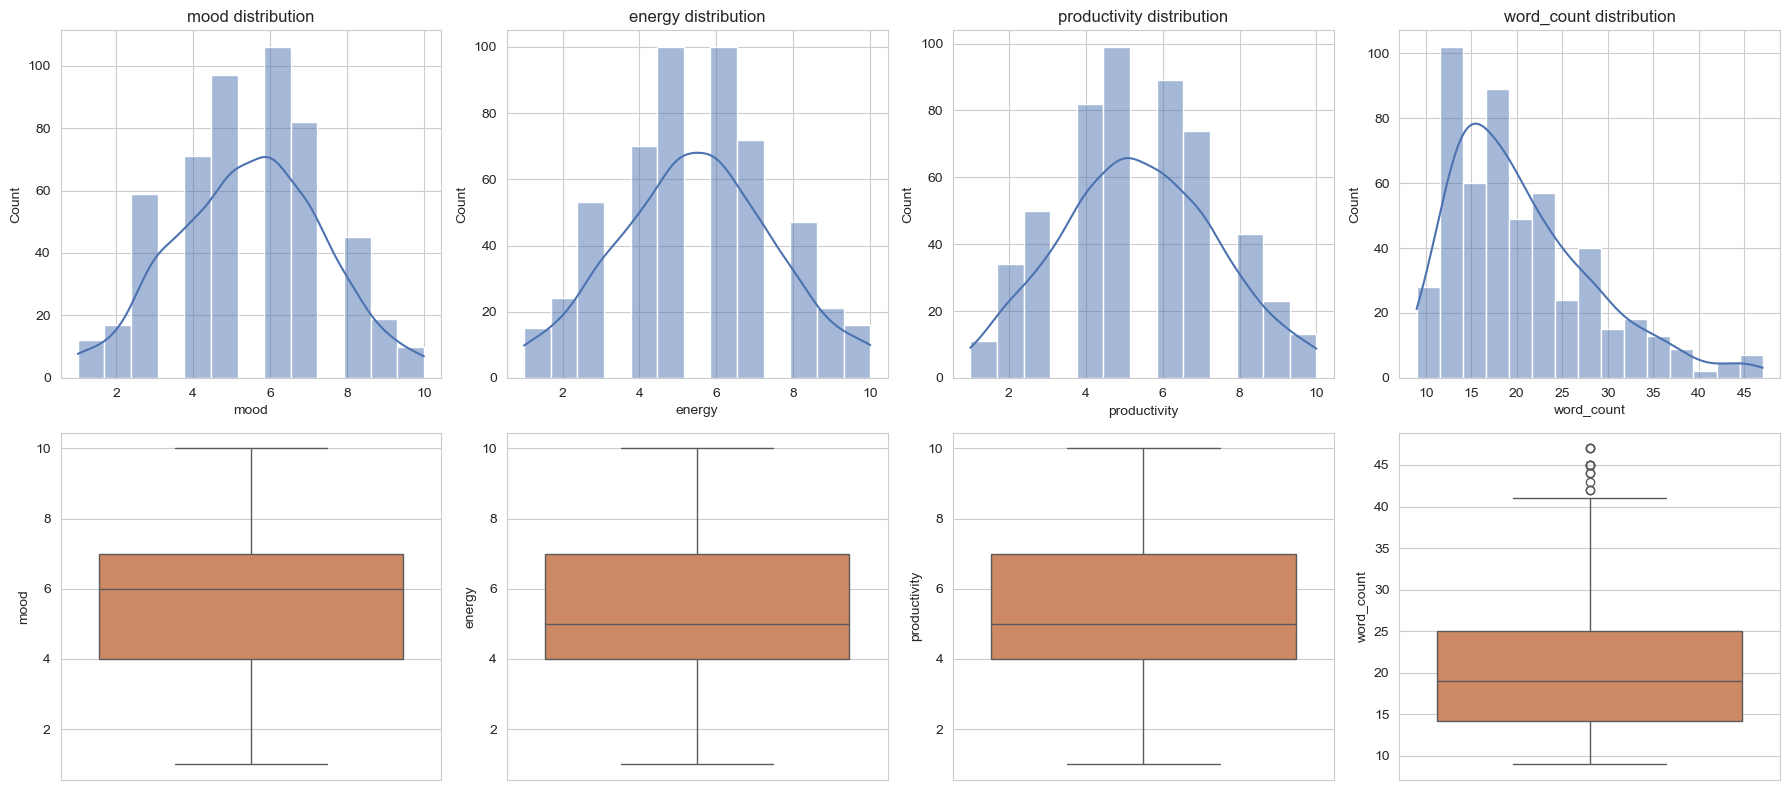

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(["mood","energy","productivity","word_count"]):
    sns.histplot(df[col], kde=True, ax=axes[0, i], color="#4C72B0")
    axes[0, i].set_title(f"{col} distribution")
    sns.boxplot(y=df[col], ax=axes[1, i], color="#DD8452")
plt.tight_layout()
plt.savefig("visualizations/univariate_numerical.png", dpi=110, bbox_inches="tight")
plt.show()

## Cell 9 — EDA: correlation heatmap

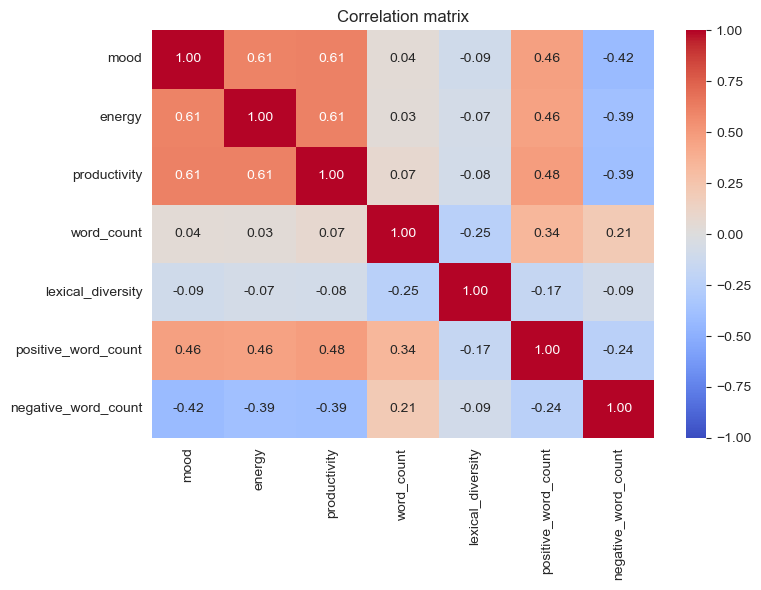

,mood,energy,productivity,word_count,lexical_diversity,positive_word_count,negative_word_count
mood,1.00,0.61,0.61,0.04,-0.09,0.46,-0.42
energy,0.61,1.00,0.61,0.03,-0.07,0.46,-0.39
productivity,0.61,0.61,1.00,0.07,-0.08,0.48,-0.39
word_count,0.04,0.03,0.07,1.00,-0.25,0.34,0.21
lexical_diversity,-0.09,-0.07,-0.08,-0.25,1.00,-0.17,-0.09
positive_word_count,0.46,0.46,0.48,0.34,-0.17,1.00,-0.24
negative_word_count,-0.42,-0.39,-0.39,0.21,-0.09,-0.24,1.00


In [12]:
corr_cols = ["mood","energy","productivity","word_count","lexical_diversity","positive_word_count","negative_word_count"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.savefig("visualizations/correlation_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

corr_matrix.round(2)

## Cell 10 — EDA: time series with 7-day rolling average

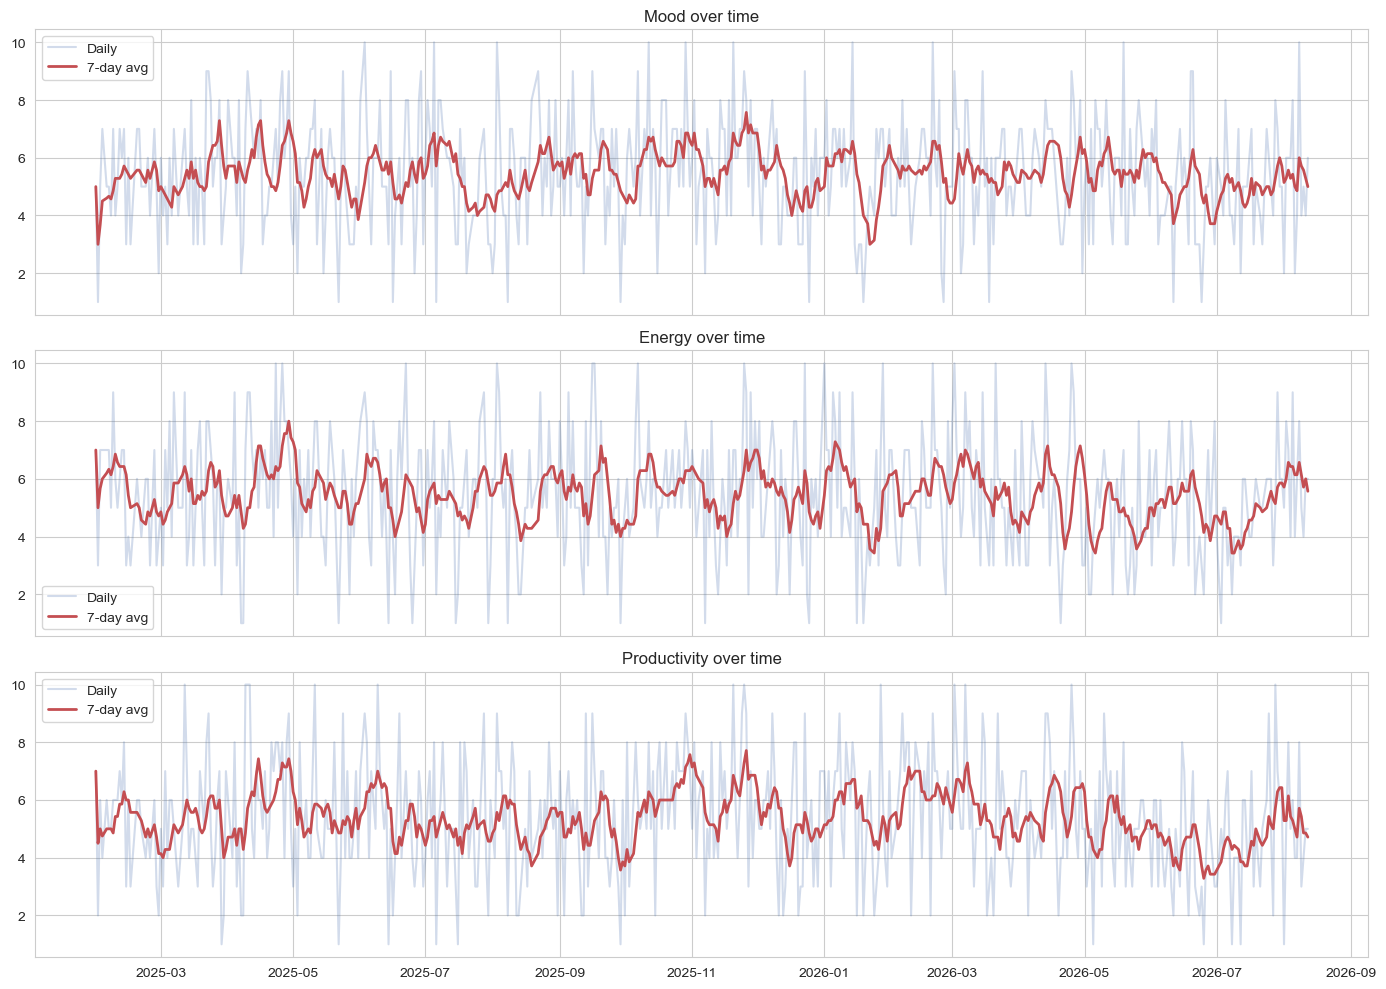

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, col in zip(axes, ["mood","energy","productivity"]):
    ax.plot(df["date"], df[col], alpha=0.25, color="#4C72B0", label="Daily")
    ax.plot(df["date"], df[f"rolling_7day_{col}"], color="#C44E52", linewidth=2, label="7-day avg")
    ax.set_title(f"{col.capitalize()} over time")
    ax.legend()
plt.tight_layout()
plt.savefig("visualizations/time_series_trends.png", dpi=110, bbox_inches="tight")
plt.show()

## Cell 11 — Streak analysis + save feature-engineered data

In [14]:
all_dates = pd.to_datetime(df["date"]).sort_values().reset_index(drop=True)
date_range = pd.date_range(all_dates.min(), all_dates.max(), freq="D")
written = set(all_dates.dt.date)

current_streak = 0
for d in reversed(date_range):
    if d.date() in written:
        current_streak += 1
    else:
        break

streaks, current = [], 0
for d in date_range:
    if d.date() in written:
        current += 1
    else:
        current = 0
    streaks.append(current)
longest_streak = max(streaks)
consistency = len(written) / len(date_range)

print(f"Consistency: {consistency:.1%}")
print(f"Longest streak: {longest_streak} days")
print(f"Current streak: {current_streak} days")

df.to_csv("data/processed/reflections_with_features.csv", index=False)
print("Saved data/processed/reflections_with_features.csv")

Consistency: 92.5%
Longest streak: 55 days
Current streak: 20 days
Saved data/processed/reflections_with_features.csv


## Cell 12 — NLP: word frequency

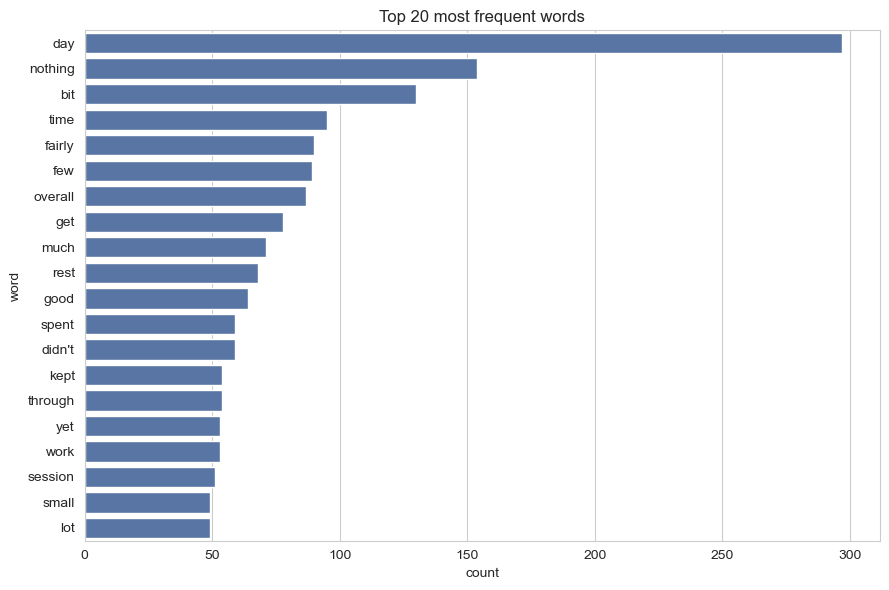

In [15]:
df["token_text"] = df["tokens"].apply(lambda t: " ".join(t))
all_tokens = [t for toks in df["tokens"] for t in toks]
word_freq = Counter(all_tokens)

freq_df = pd.DataFrame(word_freq.most_common(20), columns=["word","count"])
fig, ax = plt.subplots(figsize=(9,6))
sns.barplot(data=freq_df, y="word", x="count", ax=ax, color="#4C72B0")
ax.set_title("Top 20 most frequent words")
plt.tight_layout()
plt.savefig("visualizations/word_frequency.png", dpi=110, bbox_inches="tight")
plt.show()

## Cell 13 — NLP: bigrams/trigrams + TF-IDF

In [16]:
EXTRA_STOPWORDS = ["day","bit","today","fairly","didn","felt","time","really","just","particularly","overall","much","few","get","nothing"]

def top_ngrams(text_series, n, top_k=15):
    cv = CountVectorizer(ngram_range=(n, n), max_features=top_k, stop_words=EXTRA_STOPWORDS)
    matrix = cv.fit_transform(text_series)
    counts = matrix.sum(axis=0).A1
    return sorted(zip(cv.get_feature_names_out(), counts), key=lambda x: -x[1])

print("Top bigrams:", top_ngrams(df["token_text"], 2)[:10])
print("\nTop trigrams:", top_ngrams(df["token_text"], 3)[:10])

tfidf = TfidfVectorizer(max_features=25, stop_words=EXTRA_STOPWORDS)
tfidf_matrix = tfidf.fit_transform(df["token_text"])
mean_scores = tfidf_matrix.mean(axis=0).A1
tfidf_df = pd.DataFrame({"term": tfidf.get_feature_names_out(), "avg_tfidf": mean_scores}).sort_values("avg_tfidf", ascending=False)
tfidf_df.head(15)

Top bigrams: [('lazy mixed', np.int64(36)), ('mixed rest', np.int64(36)), ('rest small', np.int64(36)), ('small chores', np.int64(36)), ('average work', np.int64(29)), ('mostly handled', np.int64(29)), ('without excitement', np.int64(29)), ('work mostly', np.int64(29)), ('backlog emails', np.int64(27)), ('quiet spoke', np.int64(27))]

Top trigrams: [('lazy mixed rest', np.int64(36)), ('mixed rest small', np.int64(36)), ('rest small chores', np.int64(36)), ('average work mostly', np.int64(29)), ('work mostly handled', np.int64(29)), ('ready see what', np.int64(26)), ('see what tomorrow', np.int64(26)), ('what tomorrow brings', np.int64(26)), ('all things considered', np.int64(25)), ('haven started preparing', np.int64(25))]


,term,avg_tfidf
19,through,0.084716
17,spent,0.067997
14,rest,0.066341
2,good,0.060634
23,work,0.058054
6,kept,0.057544
8,lot,0.057307
3,great,0.057183
10,more,0.055987
15,session,0.054558


## Cell 14 — NLP: VADER sentiment

In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores["compound"]
    label = "positive" if compound >= 0.05 else ("negative" if compound <= -0.05 else "neutral")
    return pd.Series({"sentiment_label": label, "sentiment_score": compound})

sentiment_results = df["raw_reflection"].apply(get_sentiment)
df = pd.concat([df, sentiment_results], axis=1)

r_mood, p_mood = stats.pearsonr(df["sentiment_score"], df["mood"])
print(f"Sentiment vs mood: r = {r_mood:.3f}, p = {p_mood:.4f}")

df.to_csv("data/processed/reflections_with_sentiment.csv", index=False)
print("Saved final dataset")
df["sentiment_label"].value_counts()

Sentiment vs mood: r = 0.517, p = 0.0000
Saved final dataset


sentiment_label
negative    203
positive    193
neutral     122
Name: count, dtype: int64

# LDA runs and produces reasonably distinct topics. Now let's build Notebook 4's code (Emotion + Topic Analysis).

## Cell 1 — Load data (works whether or not you've run the VADER cell yet)

In [18]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)

# Use the sentiment file if you've already run Notebook 3's VADER cell, else fall back
path = "data/processed/reflections_with_sentiment.csv" if os.path.exists("data/processed/reflections_with_sentiment.csv") else "data/processed/reflections_with_features.csv"
df = pd.read_csv(path)
df["date"] = pd.to_datetime(df["date"])
df["tokens"] = df["tokens"].apply(ast.literal_eval)
df["token_text"] = df["tokens"].apply(lambda t: " ".join(t))
print("Loaded:", path, "-", df.shape)
df.head()

Loaded: data/processed/reflections_with_sentiment.csv - (518, 31)


,date,reflection,mood,energy,productivity,tags,date_parsed,raw_reflection,cleaned_reflection,tokens,...,average_word_length,lexical_diversity,positive_word_count,negative_word_count,rolling_7day_mood,rolling_7day_energy,rolling_7day_productivity,token_text,sentiment_label,sentiment_score
0,2025-01-30,"Spent some time reviewing machine learning, mostly going over gradient descent again.",5,7,7,coding,2025-01-30,"Spent some time reviewing machine learning, mostly going over gradient descent again.","spent some time reviewing machine learning, mostly going over gradient descent again.","[spent, time, reviewing, machine, learning, mostly, going, gradient, descent]",...,6.166667,0.750000,0,0,5.000000,7.000000,7.00,spent time reviewing machine learning mostly going gradient descent,neutral,0.0000
1,2025-01-31,Tried to study data visualization today but kept getting stuck on overfitting and felt frustrated. Need to get more ...,1,3,2,"python, study, data science",2025-01-31,Tried to study data visualization today but kept getting stuck on overfitting and felt frustrated. Need to get more ...,tried to study data visualization today but kept getting stuck on overfitting and felt frustrated. need to get more ...,"[tried, study, data, visualization, kept, getting, stuck, overfitting, frustrated, need, get, more, rest, tonight]",...,5.190476,0.666667,0,1,3.000000,5.000000,4.50,tried study data visualization kept getting stuck overfitting frustrated need get more rest tonight,negative,-0.7964
2,2025-02-01,"Fairly lazy day overall, mixed a bit of rest with a few small chores. Nothing particularly stands out about today.",5,7,6,"weekend, rest",2025-02-01,"Fairly lazy day overall, mixed a bit of rest with a few small chores. Nothing particularly stands out about today.","fairly lazy day overall, mixed a bit of rest with a few small chores. nothing particularly stands out about today.","[fairly, lazy, day, overall, mixed, bit, rest, few, small, chores, nothing, stands]",...,4.750000,0.600000,0,0,3.666667,5.666667,5.00,fairly lazy day overall mixed bit rest few small chores nothing stands,negative,-0.3612
3,2025-02-02,Read through some notes on feature engineering but didn't get much hands-on SQL practice done.,7,7,4,study,2025-02-02,Read through some notes on feature engineering but didn't get much hands-on SQL practice done.,read through some notes on feature engineering but didn't get much hands-on sql practice done.,"[read, through, notes, feature, engineering, didn't, get, much, hands, sql, practice, done]",...,5.333333,0.800000,0,0,4.500000,6.000000,4.75,read through notes feature engineering didn't get much hands sql practice done,neutral,0.0000
4,2025-02-04,Thinking about the exam a lot today but haven't really started preparing yet. Nothing particularly stands out about ...,5,7,6,"stress, anxiety",2025-02-04,Thinking about the exam a lot today but haven't really started preparing yet. Nothing particularly stands out about ...,thinking about the exam a lot today but haven't really started preparing yet. nothing particularly stands out about ...,"[thinking, exam, lot, haven't, started, preparing, yet, nothing, stands]",...,5.473684,0.473684,0,0,4.600000,6.200000,5.00,thinking exam lot haven't started preparing yet nothing stands,neutral,0.0000


## Cell 2 — Emotion classification

In [20]:
try:
    from transformers import pipeline

    emotion_classifier = pipeline(
        "text-classification",
        model="j-hartmann/emotion-english-distilroberta-base",
        top_k=1,
    )

    def classify_emotion(text):
        result = emotion_classifier(str(text)[:512])[0][0]  # truncate long text, take top emotion
        return pd.Series({"emotion": result["label"], "emotion_score": result["score"]})

    emotion_results = df["raw_reflection"].apply(classify_emotion)
    df = pd.concat([df, emotion_results], axis=1)
    print("Emotion classification complete.")
    print(df["emotion"].value_counts())

except ImportError:
    print("transformers/torch not installed. Run: pip install transformers torch")
    print("Skipping emotion classification for now — the rest of this notebook still works without it.")

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

C:\Users\ASUS\.anaconda\anaconda2\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--j-hartmann--emotion-english-distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  329MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

model.safetensors: downloading bytes:           |  0.00B            

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Emotion classification complete.
emotion
neutral     169
joy         163
sadness     122
fear         44
surprise     10
anger         9
disgust       1
Name: count, dtype: int64


## Cell 3 — Markdown

### Important note on emotion classification

* This model performs **NLP text classification only** — it detects which emotion category the *wording* of a sentence statistically resembles, based on patterns learned from a labeled training dataset. It is **not** a psychological or medical assessment, and no output from it should be interpreted as a mental health diagnosis of the writer.

## Cell 4 — Emotion distribution and relationship to mood

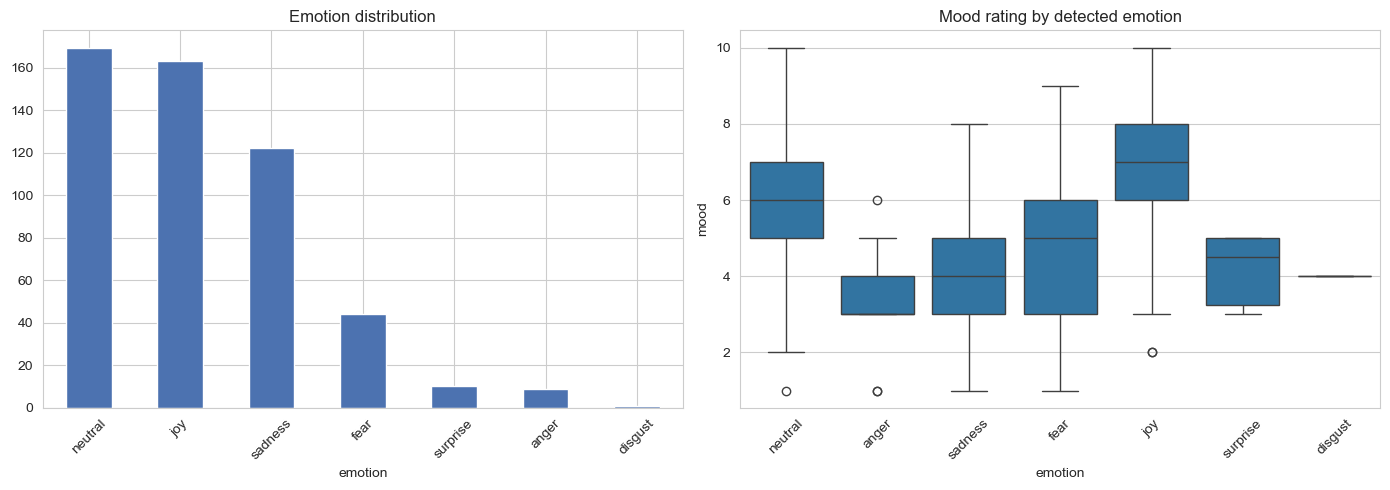

In [23]:
if "emotion" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df["emotion"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title("Emotion distribution")
    axes[0].tick_params(axis="x", rotation=45)

    sns.boxplot(data=df, x="emotion", y="mood", ax=axes[1])
    axes[1].set_title("Mood rating by detected emotion")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig("visualizations/emotion_analysis.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("No emotion column — run Cell 2 successfully first.")

## Cell 5 — Emotion over time

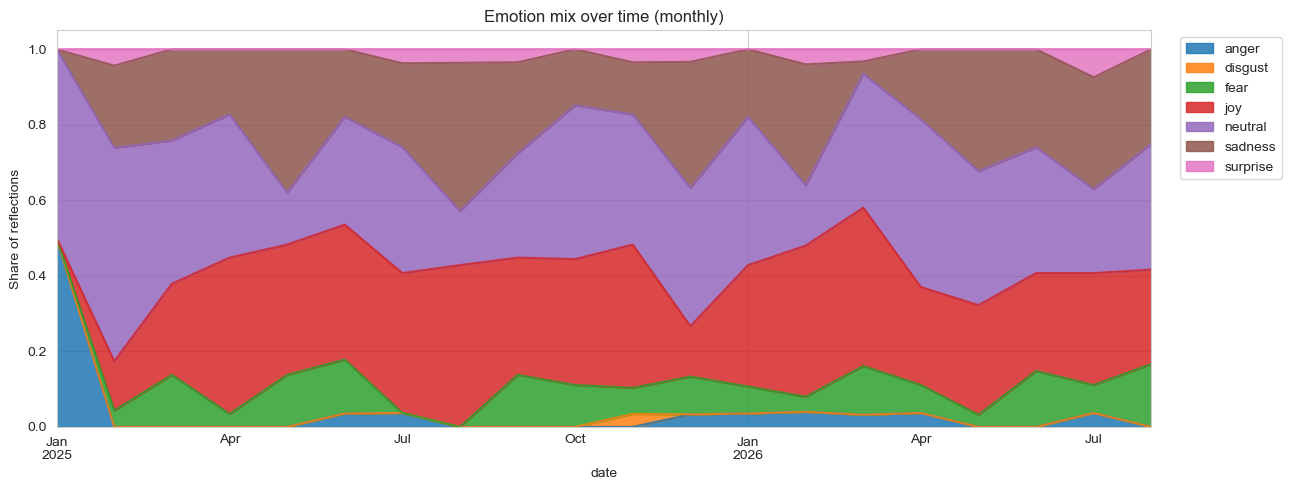

In [24]:
if "emotion" in df.columns:
    emotion_over_time = df.set_index("date").groupby([pd.Grouper(freq="ME"), "emotion"]).size().unstack(fill_value=0)
    emotion_share = emotion_over_time.div(emotion_over_time.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(13, 5))
    emotion_share.plot(kind="area", stacked=True, ax=ax, alpha=0.85)
    ax.set_title("Emotion mix over time (monthly)")
    ax.set_ylabel("Share of reflections")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("visualizations/emotion_over_time.png", dpi=110, bbox_inches="tight")
    plt.show()

## Cell 6 — Topic modeling with LDA

In [25]:
EXTRA_STOPWORDS = ["day","bit","today","fairly","didn","felt","time","really","just",
                    "particularly","overall","much","few","get","nothing"]

cv = CountVectorizer(max_features=500, stop_words=EXTRA_STOPWORDS, min_df=3)
doc_term_matrix = cv.fit_transform(df["token_text"])
print("Document-term matrix shape:", doc_term_matrix.shape)

N_TOPICS = 7
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=25, learning_method="batch")
lda.fit(doc_term_matrix)

feature_names = cv.get_feature_names_out()
topic_labels = {}
for idx, topic in enumerate(lda.components_):
    top_terms = [feature_names[i] for i in topic.argsort()[-8:][::-1]]
    topic_labels[idx] = ", ".join(top_terms[:4])
    print(f"Topic {idx}: {top_terms}")

Document-term matrix shape: (518, 314)
Topic 0: ['spent', 'work', 'most', 'handled', 'average', 'excitement', 'without', 'yet']
Topic 1: ['small', 'rest', 'chores', 'lazy', 'mixed', 'tomorrow', 'brings', 'see']
Topic 2: ['preparing', 'lot', 'started', 'feeling', 'thinking', 'haven', 'yet', 'interview']
Topic 3: ['session', 'skipped', 'well', 'kept', 'habit', 'light', 'intense', 'reasonably']
Topic 4: ['done', 'through', 'kept', 'getting', 'struggled', 'focus', 'overfitting', 'causation']
Topic 5: ['not', 'more', 'couldn', 'find', 'motivation', 'wanted', 'spend', 'lately']
Topic 6: ['good', 'phone', 'spoke', 'quiet', 'needed', 'friend', 'great', 'messages']


## Cell 7 — Assign dominant topic to each reflection

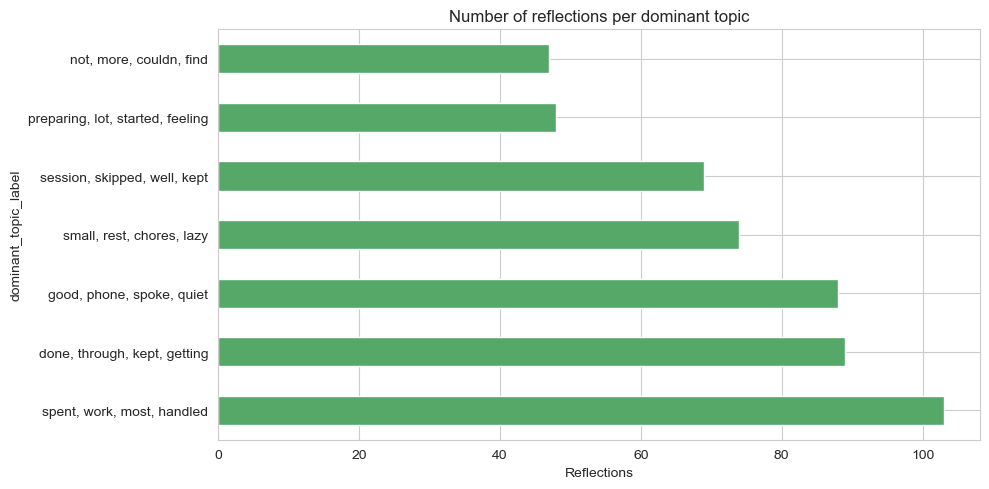

In [26]:
topic_distribution = lda.transform(doc_term_matrix)
df["dominant_topic"] = topic_distribution.argmax(axis=1)
df["dominant_topic_label"] = df["dominant_topic"].map(topic_labels)

topic_counts = df["dominant_topic_label"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
topic_counts.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Number of reflections per dominant topic")
ax.set_xlabel("Reflections")
plt.tight_layout()
plt.savefig("visualizations/topic_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

## Cell 8 — Topic frequency over time

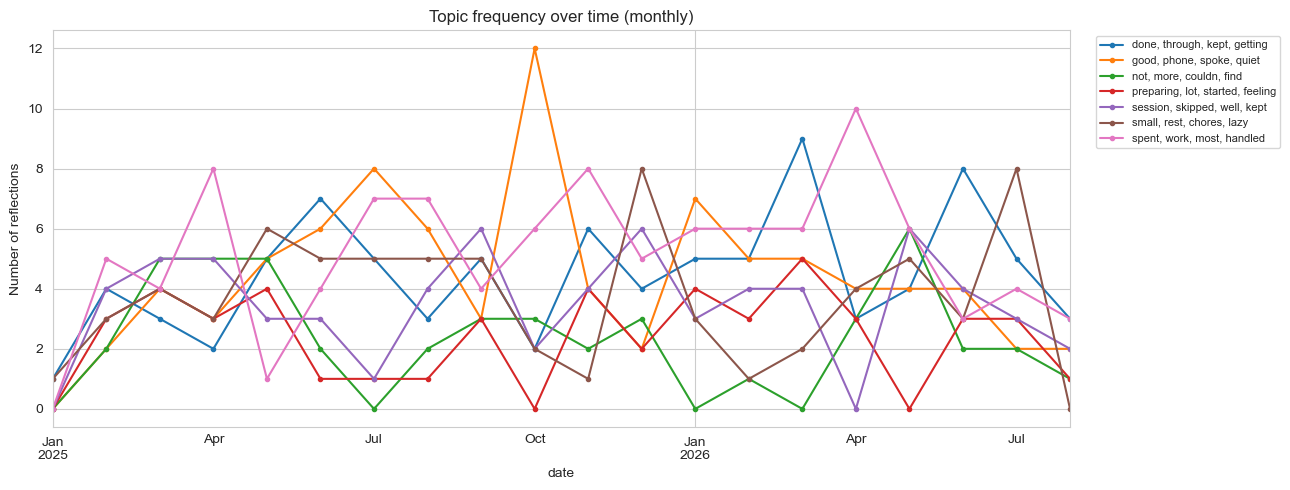

In [27]:
topic_over_time = df.set_index("date").groupby([pd.Grouper(freq="ME"), "dominant_topic_label"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
topic_over_time.plot(ax=ax, marker="o", markersize=3)
ax.set_title("Topic frequency over time (monthly)")
ax.set_ylabel("Number of reflections")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("visualizations/topic_over_time.png", dpi=110, bbox_inches="tight")
plt.show()

## Cell 9 — Topic vs mood/productivity

In [28]:
topic_vs_ratings = df.groupby("dominant_topic_label")[["mood", "energy", "productivity"]].mean().round(2)
topic_vs_ratings["count"] = df["dominant_topic_label"].value_counts()
topic_vs_ratings.sort_values("mood", ascending=False)

,mood,energy,productivity,count
dominant_topic_label,,,,
"good, phone, spoke, quiet",6.60,6.39,6.51,88
"preparing, lot, started, feeling",6.15,6.44,6.17,48
"spent, work, most, handled",5.88,5.68,5.84,103
"small, rest, chores, lazy",5.51,5.68,5.11,74
"done, through, kept, getting",4.88,4.79,4.74,89
"session, skipped, well, kept",4.49,4.83,4.64,69
"not, more, couldn, find",4.23,4.17,4.13,47


## Cell 10 — Save

In [29]:
df.to_csv("data/processed/reflections_with_topics.csv", index=False)
print(f"Saved {len(df)} records with topic assignments to data/processed/reflections_with_topics.csv")

Saved 518 records with topic assignments to data/processed/reflections_with_topics.csv


# Notebook 5: Machine Learning.

## Cell 1 — Load data and build lag/target features

In [30]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

path = "data/processed/reflections_with_topics.csv" if os.path.exists("data/processed/reflections_with_topics.csv") else "data/processed/reflections_with_features.csv"
df = pd.read_csv(path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
print("Loaded:", path, "-", df.shape)

Loaded: data/processed/reflections_with_topics.csv - (518, 35)


## Cell 2 — Markdown

## Cell 3 — Feature engineering + chronological split

In [31]:
for col in ["mood", "energy", "productivity"]:
    df[f"prev_{col}"] = df[col].shift(1)
df["prev_word_count"] = df["word_count"].shift(1)
df["target_next_productivity"] = df["productivity"].shift(-1)

feature_cols = ["prev_mood", "prev_energy", "prev_productivity", "prev_word_count",
                "rolling_7day_mood", "rolling_7day_productivity", "day_of_week_num", "is_weekend"]

model_df = df.dropna(subset=feature_cols + ["target_next_productivity"]).reset_index(drop=True)
print("Rows available for modeling:", len(model_df))

X = model_df[feature_cols].copy()
X["is_weekend"] = X["is_weekend"].astype(int)
y = model_df["target_next_productivity"]

split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Rows available for modeling: 516
Train: 412 rows | Test: 104 rows


## Cell 4 — Train and evaluate three models, plus a baseline

In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=5),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, random_state=42, max_depth=3),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "model": name,
        "MAE": round(mean_absolute_error(y_test, preds), 3),
        "RMSE": round(mean_squared_error(y_test, preds) ** 0.5, 3),
        "R2": round(r2_score(y_test, preds), 3),
    })

# Baseline: always predict the training-set mean — the benchmark any real model must beat
baseline_preds = [y_train.mean()] * len(y_test)
results.append({
    "model": "Baseline (predict mean)",
    "MAE": round(mean_absolute_error(y_test, baseline_preds), 3),
    "RMSE": round(mean_squared_error(y_test, baseline_preds) ** 0.5, 3),
    "R2": round(r2_score(y_test, baseline_preds), 3),
})

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE,R2
0,Linear Regression,1.644,2.029,-0.107
1,Random Forest,1.675,2.052,-0.132
2,Gradient Boosting,1.783,2.181,-0.279
3,Baseline (predict mean),1.658,2.037,-0.116


## Cell - 5 Markdown

## Cell 6 — Feature importance

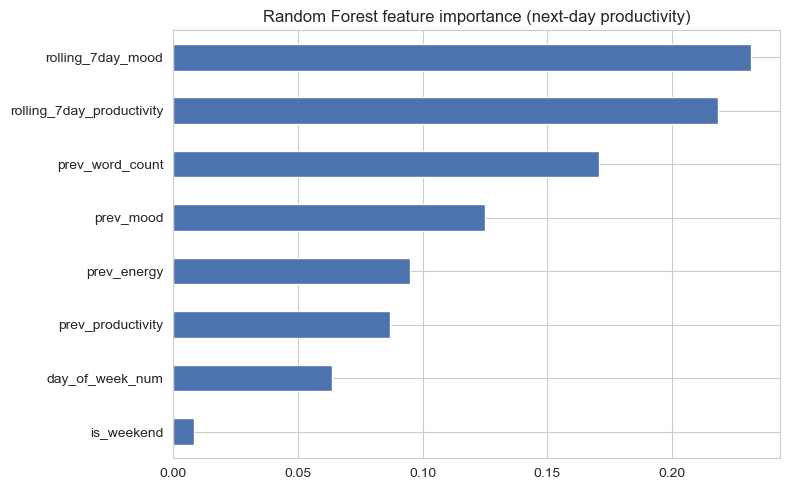

rolling_7day_mood            0.231664
rolling_7day_productivity    0.218464
prev_word_count              0.170830
prev_mood                    0.125152
prev_energy                  0.094978
prev_productivity            0.086933
day_of_week_num              0.063695
is_weekend                   0.008284
dtype: float64

In [33]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Random Forest feature importance (next-day productivity)")
plt.tight_layout()
plt.savefig("visualizations/feature_importance.png", dpi=110, bbox_inches="tight")
plt.show()

importances

## Cell 7 — Model comparison chart

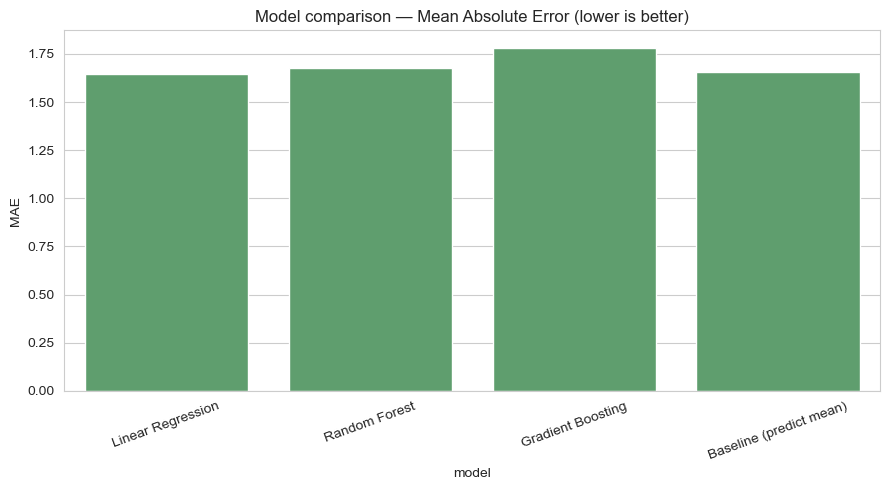

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=results_df, x="model", y="MAE", ax=ax, color="#55A868")
ax.set_title("Model comparison — Mean Absolute Error (lower is better)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("visualizations/model_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

## Cell 8 — Save results

In [35]:
results_df.to_csv("data/processed/model_comparison.csv", index=False)
model_df.assign(predicted=models["Linear Regression"].predict(X)).to_csv("data/processed/predictions.csv", index=False)
print("Saved model comparison and predictions.")

Saved model comparison and predictions.


# Reflection Tree Visualization

## Cell 1 — Build the tree

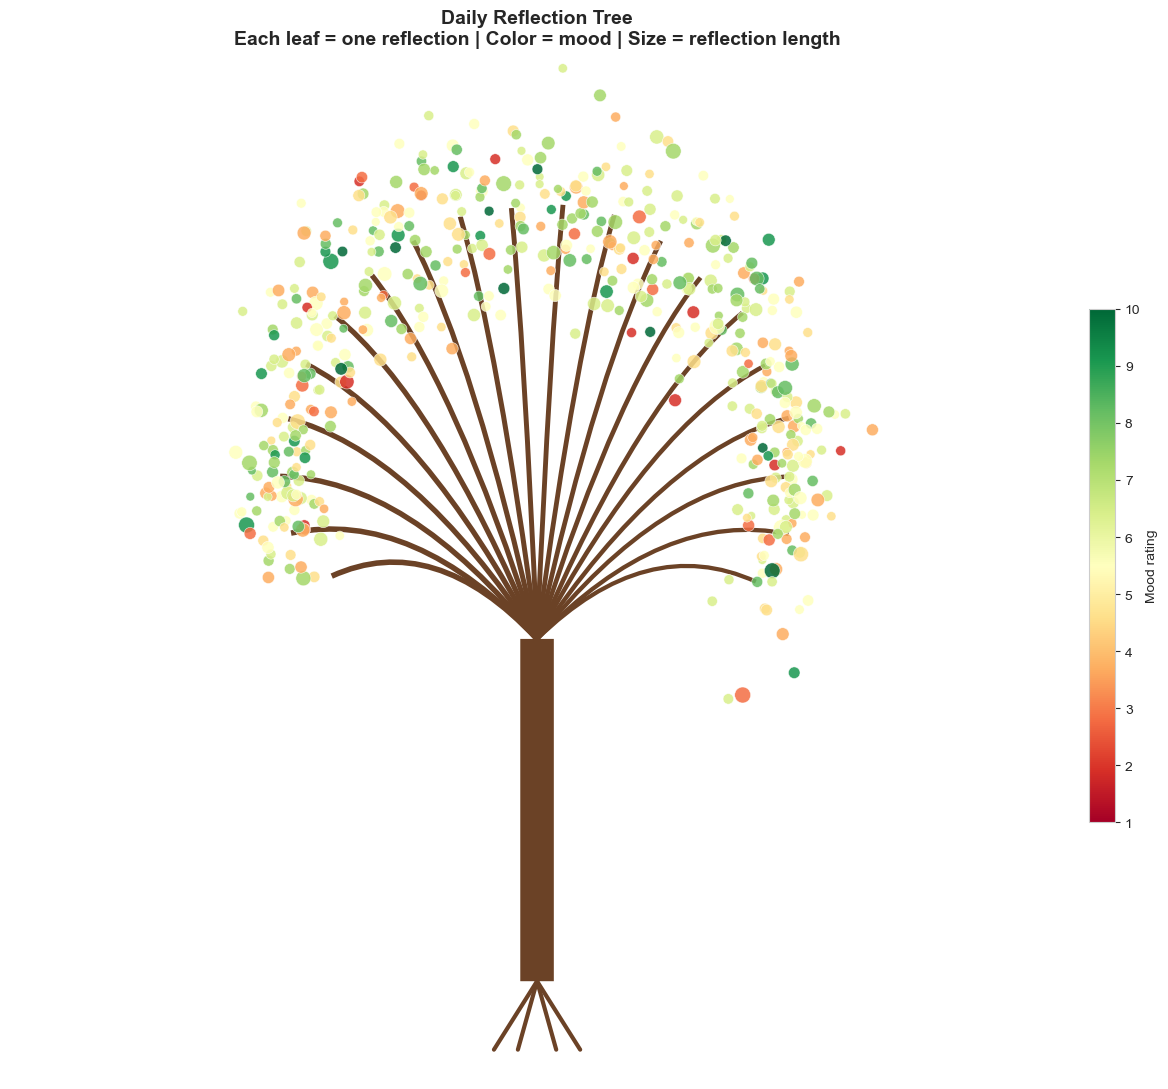

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import os

df = pd.read_csv("data/processed/reflections_with_features.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df["year_month"] = df["date"].dt.to_period("M")

months = sorted(df["year_month"].unique())
n_months = len(months)

fig, ax = plt.subplots(figsize=(13, 11))
ax.set_xlim(-11, 11)
ax.set_ylim(-1, 9.5)
ax.axis("off")

# Trunk — represents overall consistency/longevity of the journaling habit
trunk_height = 3.5
ax.add_patch(mpatches.FancyBboxPatch((-0.35, 0), 0.7, trunk_height,
             boxstyle="round,pad=0", fc="#6b4226", ec="none"))

# Roots — the beginning of the journaling journey
for dx in [-0.9, -0.4, 0.4, 0.9]:
    ax.plot([0, dx], [0, -0.7], color="#6b4226", linewidth=3, solid_capstyle="round")

# Branches — one per calendar month, fanning outward from the top of the trunk;
# branch length scales gently with how many reflections that month has
branch_base = (0, trunk_height)
angles = np.linspace(200, -20, n_months)
branch_length_base = 4.5

branch_endpoints = []
for i, (month, angle) in enumerate(zip(months, angles)):
    rad = np.radians(angle)
    month_count = (df["year_month"] == month).sum()
    length = branch_length_base + 0.03 * month_count
    end_x = branch_base[0] + length * np.cos(rad)
    end_y = branch_base[1] + length * np.sin(rad) * 0.55 + 1.5
    branch_endpoints.append((end_x, end_y))

    mid_x = branch_base[0] + (end_x - branch_base[0]) * 0.5
    mid_y = branch_base[1] + (end_y - branch_base[1]) * 0.5 + 0.8
    verts = [branch_base, (mid_x, mid_y), (end_x, end_y)]
    codes = [Path.MOVETO, Path.CURVE3, Path.CURVE3]
    path = Path(verts, codes)
    ax.add_patch(mpatches.PathPatch(path, facecolor="none", edgecolor="#6b4226", lw=max(1.5, 4 - i * 0.05)))

# Leaves — one per reflection: color = mood, size = reflection length (word count)
cmap = plt.cm.RdYlGn
rng = np.random.default_rng(42)
for month, (ex, ey) in zip(months, branch_endpoints):
    month_df = df[df["year_month"] == month]
    n = len(month_df)
    xs = ex + rng.normal(0, 0.55, n)
    ys = ey + rng.normal(0, 0.55, n)
    colors = cmap(month_df["mood"] / 10)
    sizes = 15 + month_df["word_count"] * 2.5
    ax.scatter(xs, ys, s=sizes, c=colors, alpha=0.85, edgecolors="white", linewidths=0.4, zorder=5)

ax.set_title("Daily Reflection Tree\nEach leaf = one reflection | Color = mood | Size = reflection length",
              fontsize=14, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(1, 10))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Mood rating")

plt.tight_layout()
os.makedirs("visualizations", exist_ok=True)
plt.savefig("visualizations/reflection_tree.png", dpi=130, bbox_inches="tight")
plt.show()

## The Reflection Tree

**Roots** — the beginning of the journaling journey.
**Trunk** — overall consistency, the foundation everything else grows from.
**Branches** — one per month; slightly longer branches had more reflections that month.
**Leaves** — one per reflection: color encodes mood (red = low, green = high), 
size encodes how much was written that day.

This isn't decoration — every visual property maps to a real column in the dataset, 
so the tree is a genuine (if stylized) summary view of the whole project.

In [37]:
import os
print("Your notebook's current folder is:")
print(os.getcwd())
print()
print("Everything inside it:")
for item in os.listdir():
    print(" -", item)

Your notebook's current folder is:
C:\Users\ASUS\Tree

Everything inside it:
 - .ipynb_checkpoints
 - Daily_Reflection_Tree_Analysis.ipynb.ipynb
 - data
 - models
 - visualizations
